# Japan Earthquake Clustering Analysis
## ML Modeling and Evaluation

For this stage, the first step is to load the cleaned earthquake catalog and import the tools needed for the ML pipeline:

* StandardScaler → puts features on comparable scales.
* PCA → reduces dimensionality and helps identify the dominant feature combinations.
* KMeans → the clustering algorithm.
* silhouette_score → evaluates how well-separated the clusters are.
* davies_bouldin_score → another cluster-quality metric.
* matplotlib → visualization.



In [2]:
# ==================================================================
# 1. LOAD THE DATASET
# ==================================================================
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

import matplotlib.pyplot as plt

df = pd.read_csv('/content/Japan_earthquakes_cleaned.csv')

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (16815, 22)


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2026-09-05 00:22:45.357000+00:00,40.6426,143.5636,33.857,4.5,mb,18.0,177.0,1.405,0.53,...,2026-09-05T00:50:28.040Z,"159 km ENE of Noda, Japan",earthquake,7.37,7.283,0.171,10.0,reviewed,us,us
1,2026-09-04 23:52:29.825000+00:00,44.9418,149.9838,32.000,5.5,mww,105.0,82.0,5.348,1.19,...,2026-09-05T23:59:01.035Z,"168 km ESE of Kuril’sk, Russia",earthquake,9.48,1.886,0.068,21.0,reviewed,us,us
2,2026-09-01 19:21:23.337000+00:00,41.6191,142.0502,74.021,4.6,mb,85.0,114.0,0.917,0.54,...,2026-09-01T20:28:07.040Z,"78 km ENE of Mutsu, Japan",earthquake,5.65,5.698,0.061,81.0,reviewed,us,us
3,2026-08-31 09:19:57.841000+00:00,45.1453,148.2193,147.811,4.6,mb,62.0,134.0,4.145,1.06,...,2026-08-31T10:09:43.040Z,"28 km ESE of Kuril’sk, Russia",earthquake,10.91,7.505,0.048,131.0,reviewed,us,us
4,2026-08-30 00:14:19.915000+00:00,42.0423,142.6167,63.625,4.5,mb,41.0,119.0,0.404,0.72,...,2026-08-30T03:22:38.040Z,"18 km SW of Urakawa, Japan",earthquake,6.23,7.140,0.093,34.0,reviewed,us,us


Next step is defining the ML feature set, starting with key core physican and spatial variables:

In [3]:
# ==================================================================
# 2. FEATURE SELECTION
# ==================================================================
features = [
    'latitude',
    'longitude',
    'depth',
    'mag'
]

X = df[features].copy()

print("Selected ML features:")
print(features)

print("\nFeature matrix shape:", X.shape)

print("\nMissing values:")
print(X.isnull().sum())

print("\nFeature Summary:")
print(X.describe())

Selected ML features:
['latitude', 'longitude', 'depth', 'mag']

Feature matrix shape: (16815, 4)

Missing values:
latitude     0
longitude    0
depth        0
mag          0
dtype: int64

Feature Summary:
           latitude     longitude         depth           mag
count  16815.000000  16815.000000  16815.000000  16815.000000
mean      35.160317    140.337152     49.763203      4.808138
std        5.522048      5.634750     76.298630      0.373929
min       24.402600    122.917000      0.000000      4.500000
25%       30.492350    139.908850     10.000000      4.600000
50%       36.287000    141.869000     33.600000      4.700000
75%       38.826500    143.261700     49.800000      4.900000
max       45.594000    153.782000    683.360000      9.100000


We selected *latitude, longitude, depth,* and *magnitude* as our first set of features because these directly describe earthquakes themselves:

* **latitude** represents the North-South spatial position,
* **longitude** represents the East-West spatial position,
* **depth** represents the depth of the seismic event, and
* **mag** represents the earthquake magnitude.

Next, we run a missing value check:

In [4]:
# ==================================================================
# 3. MISSING VALUE CHECK
# ==================================================================
print("Missing values in ML feature matrix:")
print(X.isnull().sum())

print("\nTotal rows:", len(X))
print("Complete rows:", X.dropna().shape[0])

Missing values in ML feature matrix:
latitude     0
longitude    0
depth        0
mag          0
dtype: int64

Total rows: 16815
Complete rows: 16815


As shown above, the first four variables in the feature matrix contain no missing observations, allowing the clustering analysis to procede without imputation. Now we run feature standardization for scaling:

In [5]:
# ==================================================================
# 4. FEATURE STANDARDIZATION
# ==================================================================
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=features,
    index=X.index
)

print("Standardized feature matrix:")
print(X_scaled.head())

print("\nMeans:")
print(X_scaled.mean())

print("\nStandard deviations:")
print(X_scaled.std())

Standardized feature matrix:
   latitude  longitude     depth       mag
0  0.992828   0.572615 -0.208479 -0.824078
1  1.771403   1.712043 -0.232818  1.850303
2  1.169670   0.304024  0.317942 -0.556640
3  1.808257   1.398888  1.285091 -0.556640
4  1.246311   0.404564  0.181684 -0.824078

Means:
latitude    -7.396997e-16
longitude   -5.713076e-15
depth        4.141135e-17
mag          1.527149e-15
dtype: float64

Standard deviations:
latitude     1.00003
longitude    1.00003
depth        1.00003
mag          1.00003
dtype: float64


Standardization is essential in this stage, as without it, variables with greater numerical ranges can disproportionately influence the clustering.

In [6]:
# ==================================================================
# 5. K-MEANS: TEST CANDIDATE CLUSTERS
# ==================================================================

from sklearn.cluster import KMeans

k_values = range(2, 11)

inertia_values = []
silhouette_values = []

for k in k_values:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

  labels = kmeans.fit_predict(X_scaled)

  inertia_values.append(kmeans.inertia_)
  silhouette_values.append(silhouette_score(X_scaled, labels))

results = pd.DataFrame({
    'k': list(k_values),
    'inertia': inertia_values,
    'silhouette_score': silhouette_values
})

print(results)

    k       inertia  silhouette_score
0   2  49175.299340          0.372426
1   3  35642.553256          0.473092
2   4  26815.156086          0.444349
3   5  20031.768747          0.380914
4   6  17013.102823          0.378862
5   7  15190.779696          0.372899
6   8  14077.834673          0.367411
7   9  13244.957603          0.301695
8  10  12472.125655          0.297076


After evaluating K=2 through K=10, K = 3 is our best candidate. The silhouette schore reaches its highest value at K=3: 0.4731, then drops to 0.4443 at K=4 and continues generally downward.

It is important to note that this isn't model accuracy. In an unsupervised clustering model, there isn't an accuracy score in the convential supervised-learning sense. Instead we evaluate based on cluster quality, with our two primary metrics being Silhouette Score and Davies Bouldin Index.

Now that the candidate values have been tested, the final K-Means model can be configured.

In [7]:
# ==================================================================
# 6. FINAL K-MEANS MODEL
# ==================================================================

new_k_value = 3

kmeans = KMeans(n_clusters=new_k_value, random_state=42, n_init=10)

cluster_labels = kmeans.fit_predict(X_scaled)

df['cluster'] = cluster_labels

print("Numer of clusters:", new_k_value)
print("Random state:", 42)
print("n_init:", 10)

print("\nCluster counts:")
print(df['cluster'].value_counts().sort_index())

Numer of clusters: 3
Random state: 42
n_init: 10

Cluster counts:
cluster
0      567
1     2577
2    13671
Name: count, dtype: int64


In the above exercise, the K-Means produced three clusters, as established by our k=3 values:

* Cluster 0: 567 events (3.37%)
* Clsuter 1: 2,577 events (15.33%)
* Cluster 2: 13,671 events (81.30%)
* Total: 16,815 events

This points to a highly imbalanced cluster distribution, which gives us an important question: ***what makes clusters 0 and 1 different from cluster 2 (the large majority)?***

To answer this, a quantitative evaluation must be done first.

In [8]:
# ==================================================================
# 7. MODEL EVALUATION
# ==================================================================

silhouette = silhouette_score(X_scaled, cluster_labels)

davies_bouldin = davies_bouldin_score(X_scaled, cluster_labels)

print("MODEL EVALUATION")
print("=" * 40)

print(f"Sihlouette Score: {silhouette:.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin:.4f}")

MODEL EVALUATION
Sihlouette Score: 0.4731
Davies-Bouldin Index: 0.7502


A Silhouette Score of 0.4731 represents a moderate to meaningful cluster separation. For the Davies-Bouldin Index of 0.7502, we can see there's a relatively good cluster compactness and separation.

Next, we will profile the clsuters to identify how they differ in lattitude, longitude, depth, and magnitude.

In [9]:
# ==================================================================
# 8. CLUSTER PROFILING
# ==================================================================

cluster_profile = df.groupby('cluster')[features].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

print(cluster_profile)

        latitude                                       longitude              \
           count       mean   median      min      max     count        mean   
cluster                                                                        
0            567  32.470700  30.8067  24.5044  45.5590       567  137.844389   
1           2577  28.432561  28.0003  24.4026  45.5764      2577  128.672538   
2          13671  36.540058  37.1130  24.4160  45.5940     13671  142.639332   

                                       depth                            \
           median       min       max  count        mean median    min   
cluster                                                                  
0        138.3309  128.1534  144.5691    567  412.883071  413.5  209.3   
1        129.3045  122.9170  135.9920   2577   37.876757   25.6    1.3   
2        142.2910  133.6710  153.7820  13671   36.943541   33.6    0.0   

                   mag                             
            max  count

In [10]:
# ==================================================================
# 9. CLUSTER CENTROIDS
# ==================================================================

scaled_centroid = pd.DataFrame(kmeans.cluster_centers_, columns=features)

og_centroid = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_),
                           columns=features)

og_centroid.index.name = 'cluster'

print("Cluster centroids in original units:")
print(og_centroid)

Cluster centroids in original units:
          latitude   longitude       depth       mag
cluster                                             
0        32.492331  137.852320  412.255327  4.940896
1        28.432561  128.672538   37.876757  4.806480
2        36.539753  142.639704   36.914666  4.802924


The cluster profiling provided very useful results, as they provide a clearer picture for our model.

Using K = 3, K-means seprated the earthquakes into three different groups:

* Deep seismic cluster (Cluster 0)
* Southwestern / offshore cluster (Cluster 1)
* Dominant northeastern / eastern cluster (cluster 2)

Here, the most important finding is cluster 0, as it significantly differs from the other two primarily because of depth with a centroid around 412 km, compared to ~37 km for clusters 1 and 2. Based on these results we can determine the algorithm is indicating ***depth is contributing strongly to the clustering structure***.

In [11]:
# ==================================================================
# 10. PRINCIPAL COMPONENT ANALYSIS (PCA)
# ==================================================================

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_

print("Explained variance by principal component:")
for i, variance in enumerate(explained_variance, start=1):
    print(f"PC{i}: {variance:.4f} ({variance * 100:.2f}%)")

print("\nCumulative explained variance:")
print(np.cumsum(explained_variance))

print("\nPCA component loadings:")
loadings = pd.DataFrame(
    pca.components_,
    columns=features,
    index=[f'PC{i}' for i in range(1, len(features) + 1)]
)

print(loadings)

Explained variance by principal component:
PC1: 0.4129 (41.29%)
PC2: 0.2636 (26.36%)
PC3: 0.2358 (23.58%)
PC4: 0.0877 (8.77%)

Cumulative explained variance:
[0.41287684 0.67646841 0.91230335 1.        ]

PCA component loadings:
     latitude  longitude     depth       mag
PC1  0.701075   0.703444 -0.103462  0.054365
PC2  0.094379  -0.049323  0.683589  0.722057
PC3  0.078314   0.080719  0.719217 -0.685623
PC4 -0.702462   0.704427  0.068768  0.074833


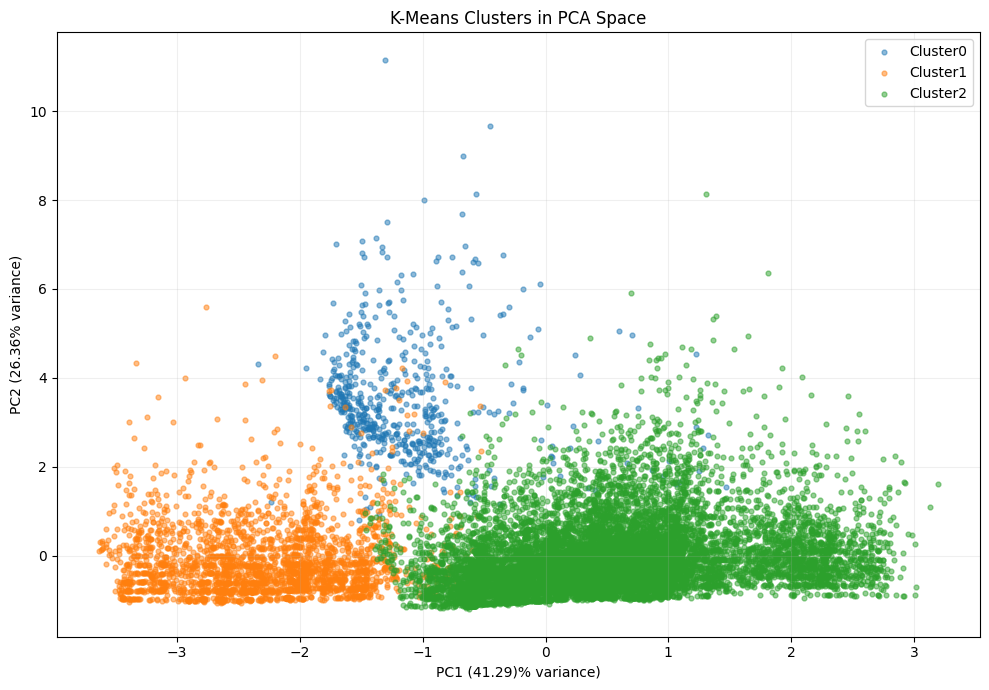

In [13]:
# ============================================================
# 11. PCA VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

#Transform standardized data into PCA
X_pca = pca.transform(X_scaled)

#Build dataframe for visualization
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3', 'PC4'], index=X.index)

#Add K-Means cluster labels
pca_df['cluster'] = kmeans.labels_

# Plot PC1 vs PC2
plt.figure(figsize=(10, 7))

for cluster in sorted(pca_df['cluster'].unique()):
  subset = pca_df[pca_df['cluster'] == cluster]

  plt.scatter(subset['PC1'], subset['PC2'], s=12, alpha=0.5, label=f'Cluster{cluster}')

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.2f})% variance)")

plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}% variance)")

plt.title("K-Means Clusters in PCA Space")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# 11. DBSCAN CLUSTERING
# ============================================================

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

# DBSCAN on standardized features
dbscan = DBSCAN(eps=0.5, min_samples=10)

dbscan_labels = dbscan.fit_predict(X_scaled)

# Add labels to dataframe
df['dbscan_cluster'] = dbscan_labels

#Number of cluster exclusing noise(-1)
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

# Number of noise points
n_noise = list(dbscan_labels).count(-1)

print("DBSCAN RESULTS")
print("=" * 40)
print("Number of clusters:", n_clusters_dbscan)
print("Noise points:", n_noise)
print("Noise percentage:", round(n_noise / len(dbscan_labels) * 100, 2), "%")

print("\nCluster counts:")
print(pd.Series(dbscan_labels).value_counts().sort_index())

DBSCAN RESULTS
Number of clusters: 5
Noise points: 444
Noise percentage: 2.64 %

Cluster counts:
-1      444
 0    15976
 1      359
 2       12
 3       14
 4       10
Name: count, dtype: int64


In [15]:
# ============================================================
# 11. DBSCAN MODEL EVALUATION
# ============================================================

# Exclude noise points from internal metrics
dbscan_mask = dbscan_labels != -1

X_dbscan_eval = X_scaled[dbscan_mask]
labels_dbscan_eval = dbscan_labels[dbscan_mask]

#Calculate evaluation metrics
dbscan_silhouette = silhouette_score(
    X_dbscan_eval,
    labels_dbscan_eval
)

dbscan_davies_bouldin = davies_bouldin_score(
    X_dbscan_eval,
    labels_dbscan_eval
)

print("DBSCAN MODEL EVALUATION")
print("=" * 40)
print("Silhouette Score:", round(dbscan_silhouette, 4))
print("Davies-Bouldin Index:", round(dbscan_davies_bouldin, 4))

DBSCAN MODEL EVALUATION
Silhouette Score: 0.4156
Davies-Bouldin Index: 0.5725


PCA shape: (16815, 4)
DBSCAN labels: 16815

DBSCAN labels in plot:
cluster
-1      444
 0    15976
 1      359
 2       12
 3       14
 4       10
Name: count, dtype: int64


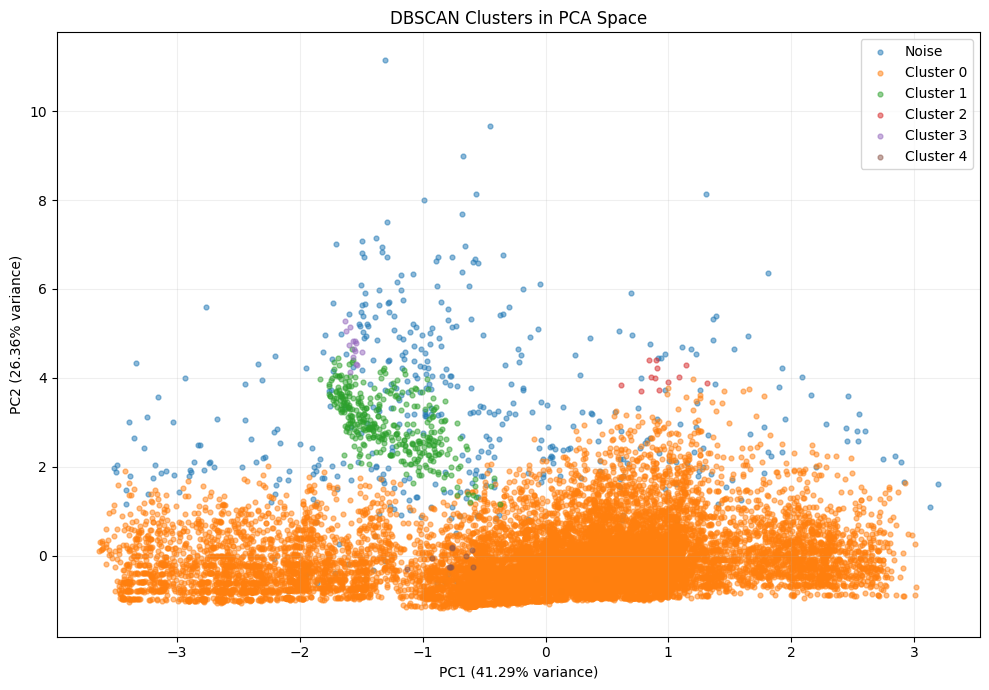

In [19]:
# ============================================================
# 12. DBSCAN VISUALIZATION IN PCA SPACE
# ============================================================

pca_dbscan = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'cluster': dbscan_labels
})

print("PCA shape:", X_pca.shape)
print("DBSCAN labels:", len(dbscan_labels))
print("\nDBSCAN labels in plot:")
print(pca_dbscan['cluster'].value_counts().sort_index())

#plot DBSCAN clusters
plt.figure(figsize=(10, 7))

for cluster in sorted(pca_dbscan['cluster'].unique()):
  subset = pca_dbscan[pca_dbscan['cluster'] == cluster]

  if cluster == -1:
    label = 'Noise'
  else:
    label = f"Cluster {cluster}"

  plt.scatter(
      subset['PC1'],
      subset['PC2'],
      s=12,
      alpha=0.5,
      label=label
  )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}% variance)")
plt.title("DBSCAN Clusters in PCA Space")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# 13. FINAL MODEL COMPARISON
# ============================================================

model_comparison = pd.DataFrame({
    'Model': ['K-Means', 'DBSCAN'],
    'Silhouette Score': [0.4731, dbscan_silhouette],
    'Davies-Bouldin Index': [0.7502, dbscan_davies_bouldin]
})

print("FINAL MODEL COMPARISON")
print('=' * 50)
print(model_comparison.to_string(index=False))

print("\nK-Means cluster distribution:")
print(df['cluster'].value_counts().sort_index())

print("\nDBSCAN cluster distribution:")
print(df['dbscan_cluster'].value_counts().sort_index())

FINAL MODEL COMPARISON
  Model  Silhouette Score  Davies-Bouldin Index
K-Means          0.473100              0.750200
 DBSCAN          0.415595              0.572532

K-Means cluster distribution:
cluster
0      567
1     2577
2    13671
Name: count, dtype: int64

DBSCAN cluster distribution:
dbscan_cluster
-1      444
 0    15976
 1      359
 2       12
 3       14
 4       10
Name: count, dtype: int64
